# 04 Content-Based Model

Bu notebook ürünlerin metinsel özelliklerini kullanarak benzer ürünleri bulur.

İçerik tabanlı iki varyant birlikte sunulur:
- TF-IDF tabanlı temel model
- SBERT tabanlı gelişmiş semantik model


In [ ]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

sns.set_theme(style="whitegrid")

PROJECT_ROOT = Path("..").resolve()
DATA_INTERIM = PROJECT_ROOT / "data_interim"

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.advanced_models import build_sbert_embeddings, build_similarity_frame_from_embeddings

products_clean = pd.read_csv(DATA_INTERIM / "products_clean.csv")
products_clean["product_id"] = products_clean["product_id"].astype(str)
products_clean["product_text"] = products_clean["product_text"].fillna("")

productid_to_index = dict(zip(products_clean["product_id"], products_clean.index))
index_to_productid = dict(zip(products_clean.index, products_clean["product_id"]))

display(products_clean[["product_name", "brand_name", "tertiary_category", "product_text"]].head())


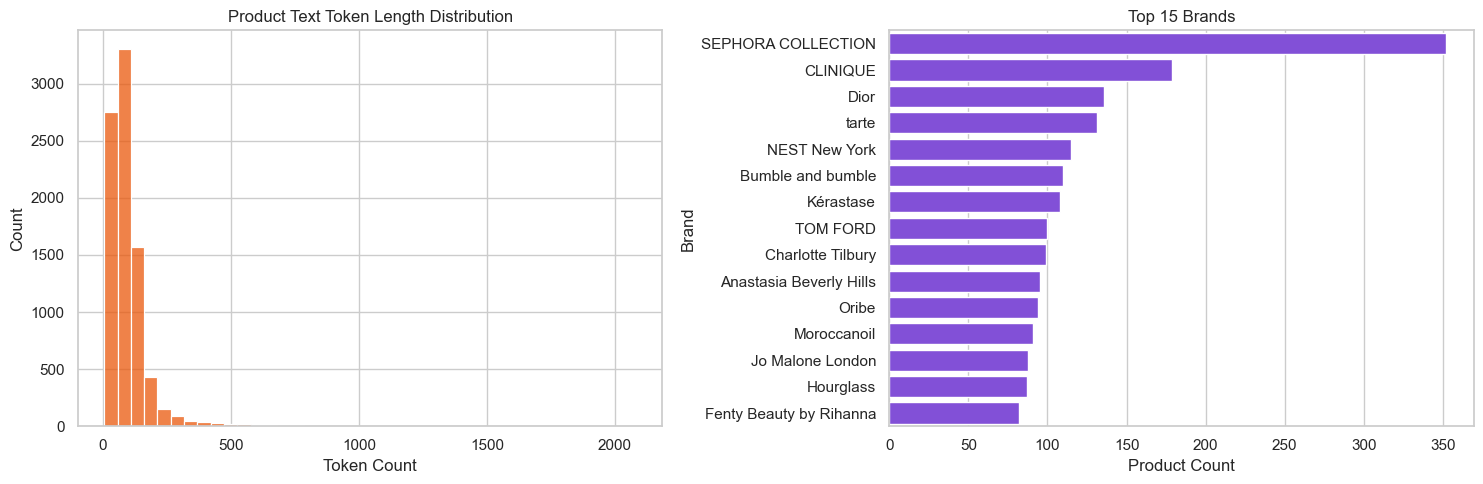

In [2]:
products_clean["token_count"] = products_clean["product_text"].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(products_clean["token_count"], bins=40, color="#EA580C", ax=axes[0])
axes[0].set_title("Product Text Token Length Distribution")
axes[0].set_xlabel("Token Count")

brand_counts = products_clean["brand_name"].fillna("Unknown").value_counts().head(15).reset_index()
brand_counts.columns = ["brand_name", "count"]
sns.barplot(data=brand_counts, x="count", y="brand_name", color="#7C3AED", ax=axes[1])
axes[1].set_title("Top 15 Brands")
axes[1].set_xlabel("Product Count")
axes[1].set_ylabel("Brand")

plt.tight_layout()


## Grafik Yorumu

Metin uzunluğu dağılımı, ürün açıklamalarının içerik tabanlı model için kullanılabilir zenginlikte olup olmadığını gösterir. Çok kısa metinler benzerlik hesaplarını zayıflatabilirken daha uzun ve bilgi yoğun metinler daha ayırt edici ürün temsilleri üretir.


## TF-IDF Representation


In [3]:
tfidf = TfidfVectorizer(stop_words="english", max_features=5000)
tfidf_matrix = tfidf.fit_transform(products_clean["product_text"])
similarity_matrix = cosine_similarity(tfidf_matrix)

productid_to_index = dict(zip(products_clean["product_id"], products_clean.index))
index_to_productid = dict(zip(products_clean.index, products_clean["product_id"]))

print("TF-IDF matrix shape:", tfidf_matrix.shape)
print("Similarity matrix shape:", similarity_matrix.shape)


TF-IDF matrix shape: (8494, 5000)
Similarity matrix shape: (8494, 8494)


In [4]:
top_terms = pd.DataFrame({
    "term": tfidf.get_feature_names_out(),
    "idf": tfidf.idf_,
}).sort_values("idf")

display(top_terms.head(20))


,term,idf
4901,water,1.400768
1920,fragrance,1.631851
4252,sodium,1.664257
228,acid,1.677380
1784,extract,1.681793
3262,oil,1.706061
2067,glycol,1.707971
310,alcohol,1.708688
426,aqua,1.760208
2060,glycerin,1.793485


## Özellik Yorumu

Düşük IDF değerine sahip terimler veri setinde daha yaygın geçen kelimeleri temsil eder. Bu tablo, ürün metinlerinde baskın olan ortak kelimeleri gözlemlemek ve gerekirse daha gelişmiş metin temizliği ihtiyacını değerlendirmek için kullanılabilir.


## Item-to-Item Recommendation Function


In [ ]:
def recommend_similar_products(product_name, top_n=10):
    matches = products_clean[
        products_clean["product_name"].str.lower().str.contains(product_name.lower(), na=False)
    ]
    if matches.empty:
        return None

    seed_index = matches.index[0]
    similarity_scores = sorted(
        list(enumerate(similarity_matrix[seed_index])),
        key=lambda x: x[1],
        reverse=True,
    )[1 : top_n + 1]

    result_indices = [idx for idx, _ in similarity_scores]
    result_scores = [score for _, score in similarity_scores]

    result = products_clean.loc[
        result_indices,
        ["product_id", "product_name", "brand_name", "tertiary_category", "rating", "price_usd"],
    ].copy()
    result["similarity_score"] = result_scores
    return result.reset_index(drop=True)


In [6]:
sample_results = recommend_similar_products("Radiant Creamy Concealer", top_n=10)
display(sample_results)


,product_id,product_name,brand_name,tertiary_category,rating,price_usd,similarity_score
0,P422077,Mini Radiant Creamy Concealer,NARS,NaN,4.1253,15.0,0.874305
1,P505043,Mini Radiant Creamy Concealer and Afterglow Li...,NARS,NaN,NaN,25.0,0.690995
2,P449107,Synchro Skin Self-Refreshing Concealer,Shiseido,Concealer,4.4394,31.0,0.594693
3,P473173,Radiant Creamy Liquid Color Corrector,NARS,Color Correct,3.5045,30.0,0.553201
4,P462720,Soft Matte Complete Foundation,NARS,Foundation,4.1135,42.0,0.538023
5,P416200,Soft Matte Complete Concealer,NARS,Concealer,4.4704,32.0,0.537174
6,P440044,Studio Skin Flawless Oil-Free 24 Hour Concealer,Smashbox,Concealer,4.3951,29.0,0.526362
7,P122914,"Airbrush Concealer Illuminates, Perfects",CLINIQUE,Concealer,4.1732,28.0,0.516906
8,P482262,Backstage Concealer,Dior,Concealer,4.4750,29.0,0.506883
9,P470512,Original Liquid Mineral Concealer,bareMinerals,Concealer,4.3244,28.0,0.497470


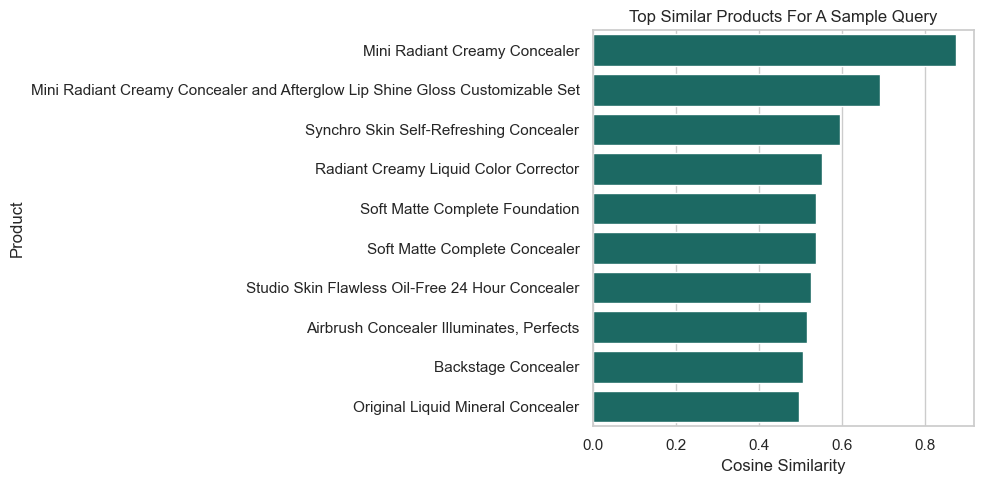

In [7]:
if sample_results is not None:
    plt.figure(figsize=(10, 5))
    sns.barplot(data=sample_results, x="similarity_score", y="product_name", color="#0F766E")
    plt.title("Top Similar Products For A Sample Query")
    plt.xlabel("Cosine Similarity")
    plt.ylabel("Product")
    plt.tight_layout()


## Sonuç Yorumu

Örnek benzer ürün grafiği, aynı veya benzer kozmetik fonksiyona sahip ürünlerin metin tabanlı olarak birbirine yakın konumlandığını göstermektedir. Bu yaklaşım özellikle kullanıcı geçmişi olmayan ancak referans ürünü bilinen senaryolarda anlamlıdır.


## Optional SBERT Extension

Bu bölüm TF-IDF ile aynı ürün metni üzerinde SBERT embedding'leri üretir. Böylece tezde content-based yaklaşımın klasik ve semantik iki varyantı aynı notebook içinde gösterilebilir.


In [ ]:
sbert_model_name = "all-MiniLM-L6-v2"
sbert_embeddings = build_sbert_embeddings(
    products_clean["product_text"],
    model_name=sbert_model_name,
    batch_size=64,
    show_progress_bar=True,
)

print("SBERT embedding shape:", sbert_embeddings.shape)


In [ ]:
def recommend_similar_products_sbert(product_name, top_n=10):
    matches = products_clean[
        products_clean["product_name"].str.lower().str.contains(product_name.lower(), na=False)
    ]
    if matches.empty:
        return None

    seed_product_id = str(matches.iloc[0]["product_id"])
    result = build_similarity_frame_from_embeddings(
        seed_product_id=seed_product_id,
        embeddings=sbert_embeddings,
        productid_to_index=productid_to_index,
        index_to_productid=index_to_productid,
        top_n=top_n,
        exclude_product_ids=[seed_product_id],
    )
    if result is None:
        return None

    enriched = result.merge(
        products_clean[
            ["product_id", "product_name", "brand_name", "tertiary_category", "rating", "price_usd"]
        ],
        on="product_id",
        how="left",
    )
    return enriched[
        ["product_id", "product_name", "brand_name", "tertiary_category", "rating", "price_usd", "similarity_score"]
    ]


sample_results_sbert = recommend_similar_products_sbert("Radiant Creamy Concealer", top_n=10)
display(sample_results_sbert)


In [ ]:
if sample_results_sbert is not None:
    plt.figure(figsize=(10, 5))
    sns.barplot(data=sample_results_sbert, x="similarity_score", y="product_name", color="#1D4ED8")
    plt.title("Top Similar Products With SBERT")
    plt.xlabel("Cosine Similarity")
    plt.ylabel("Product")
    plt.tight_layout()
